In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots






In [105]:
# read the cleaned dataset
df = pd.read_csv("../data/processed/retail_sales_dataset_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    1000 non-null   int64 
 1   date              1000 non-null   object
 2   customer_id       1000 non-null   object
 3   gender            1000 non-null   object
 4   age               1000 non-null   int64 
 5   product_category  1000 non-null   object
 6   quantity          1000 non-null   int64 
 7   price_per_unit    1000 non-null   int64 
 8   total_amount      1000 non-null   int64 
 9   year              1000 non-null   int64 
 10  month             1000 non-null   int64 
 11  month_name        1000 non-null   object
 12  weekday           1000 non-null   object
 13  age_group         1000 non-null   object
 14  age_category      1000 non-null   int64 
dtypes: int64(8), object(7)
memory usage: 117.3+ KB


In [106]:
# Create a pivot table to analyze the relationship between age groups and product categories for all customers
agegrp_pivot = pd.pivot_table(df, 
    index='age_group', 
    columns='product_category',
          values='quantity', aggfunc='sum', observed=True).fillna(0).reset_index()
agegrp_pivot

product_category,age_group,Beauty,Clothing,Electronics
0,18-24,136,112,118
1,25-34,177,183,162
2,35-44,129,216,188
3,45-54,186,194,198
4,55-64,143,189,183


In [107]:
# Create a pivot table to analyze the relationship between age groups and product categories for Female cusotmers only
df_female = df[df['gender'] == 'Female']

female_agegrp_pivot = pd.pivot_table(df_female, 
    index='age_group', 
    columns='product_category',
          values='quantity', aggfunc='sum', observed=True).fillna(0).reset_index()
female_agegrp_pivot

# Create a pivot table to analyze the relationship between age groups and product categories for Male customers
df_male = df[df['gender'] == 'Male']

male_agegrp_pivot = pd.pivot_table(df_male, 
    index='age_group', 
    columns='product_category',
          values='quantity', aggfunc='sum', observed=True).fillna(0).reset_index()
male_agegrp_pivot


product_category,age_group,Beauty,Clothing,Electronics
0,18-24,66,74,51
1,25-34,80,105,70
2,35-44,57,105,80
3,45-54,87,88,103
4,55-64,63,81,106


In [112]:
# Create a stacked bar chart to visualize the quantity of products sold by age group and product category
graph = go.Figure()

graph.add_trace(
    go.Bar(
        name= "Beauty",
        x= agegrp_pivot['age_group'], 
        y= agegrp_pivot['Beauty'],
        marker_color= "pink", 
    )
)

graph.add_trace(
    go.Bar(
        name= "Clothing",
        x= agegrp_pivot['age_group'], 
        y= agegrp_pivot['Clothing'],
        marker_color= "lightblue", 
    )
)

graph.add_trace(
    go.Bar(
        name= "Electronics",
        x= agegrp_pivot['age_group'],
        y= agegrp_pivot['Electronics'],
        marker_color= "indigo", 
    )
)

graph.update_layout(
    title= "Quantity of Products Sold by Age Group and Product Category",
    xaxis_title= "Age Group",
    yaxis_title= "Quantity Sold",
    barmode= "stack"
)
graph.show()

In [113]:
graph = make_subplots(
    rows=1, cols=2, subplot_titles=("Female", "Male"),
    shared_yaxes=True)

graph.add_trace(
    go.Bar(
        name= "Beauty",
        x= male_agegrp_pivot['age_group'], 
        y= male_agegrp_pivot['Beauty'],
        marker_color= "pink", 
    ),
    row=1, col=1
)

graph.add_trace(
    go.Bar(
        name= "Clothing",
        x= male_agegrp_pivot['age_group'], 
        y= male_agegrp_pivot['Clothing'],
        marker_color= "lightblue", 
    ),
    row=1, col=1
)

graph.add_trace(
    go.Bar(
        name= "Electronics",
        x= male_agegrp_pivot['age_group'],
        y= male_agegrp_pivot['Electronics'],
        marker_color= "indigo", 
    ),
    row=1, col=1
)


graph.add_trace(
    go.Bar(
        name= "Beauty",
        x= female_agegrp_pivot['age_group'], 
        y= female_agegrp_pivot['Beauty'],
        marker_color= "pink", 
        showlegend=False
    ), 
    row=1, col=2
)

graph.add_trace(
    go.Bar(
        name= "Clothing",
        x= female_agegrp_pivot['age_group'], 
        y= female_agegrp_pivot['Clothing'],
        marker_color= "lightblue", 
        showlegend=False,
    ),
    row=1, col=2
)

graph.add_trace(
    go.Bar(
        name= "Electronics",
        x= female_agegrp_pivot['age_group'],
        y= female_agegrp_pivot['Electronics'],
        marker_color= "indigo", 
        showlegend=False,
    ),
    row=1, col=2
)

graph.update_layout(
    title= "Quantity of Products Sold by Age Group and Product Category",
    xaxis_title= "Age Group",
    yaxis_title= "Quantity Sold",
    barmode= "stack"
)
graph.show()

In [110]:
# Create a pivot table to analyze the relationship between product categories and months
monthly_sales = df.groupby(['product_category', 'month', 'month_name'])['quantity'].sum().reset_index()
pivot_monthly_sales = monthly_sales.pivot(index=['month', 'month_name'], columns='product_category', values='quantity').fillna(0).reset_index()
pivot_monthly_sales

product_category,month,month_name,Beauty,Clothing,Electronics
0,1,Jan,62,72,65
1,2,Feb,68,75,71
2,3,Mar,51,111,32
3,4,Apr,69,93,52
4,5,May,65,97,97
5,6,Jun,66,67,64
6,7,Jul,70,45,61
7,8,Aug,62,78,87
8,9,Sep,50,60,60
9,10,Oct,83,74,95


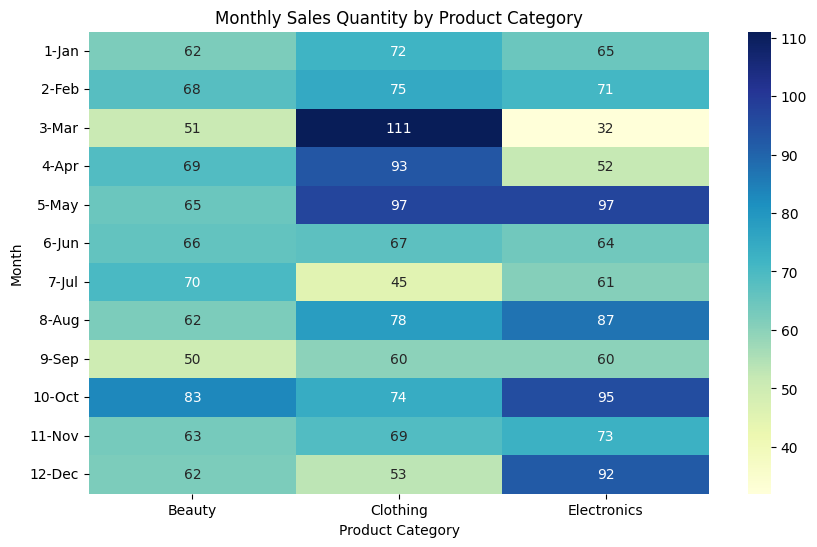

In [111]:
# Create a heatmap to visualize the quantity of products sold by month and product category
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_monthly_sales.set_index(['month', 'month_name']), annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Monthly Sales Quantity by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Month")
plt.show()